In [3]:
#Importing Libraries

In [4]:
import numpy as np
import pickle as pkl
import tensorflow as tf
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalMaxPool2D

from sklearn.neighbors import NearestNeighbors
import os
from numpy.linalg import norm

In [5]:
#Extract Filenames from Folder

In [6]:
filenames = []
for file in os.listdir('images'):
   filenames.append(os.path.join('images',file))
   
    

In [7]:
len(filenames)


44441

In [8]:
#Importing ResNet50 Model and Cofiguration

In [9]:
model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
model.trainable = False

model = tf.keras.models.Sequential([model,
                                   GlobalMaxPool2D()
                                   ])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 2048)           │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
#Extracting Fetaures from Image


In [11]:
img = image.load_img('1836.jpg', target_size=(224,224))
img_array = image.img_to_array(img)
img_expand_dim = np.expand_dims(img_array, axis=0)
img_preprocess = preprocess_input(img_expand_dim)
result = model.predict(img_preprocess).flatten()
result.shape
norm_result = result/norm(result)
norm_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([0.00613633, 0.        , 0.02705771, ..., 0.0086025 , 0.04321625,
       0.01014418], dtype=float32)

In [12]:
def extract_features_from_images(image_path, model):
    img = image.load_img(image_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_expand_dim = np.expand_dims(img_array, axis=0)
    img_preprocess = preprocess_input(img_expand_dim)
    result = model.predict(img_preprocess).flatten()
    norm_result = result/norm(result)
    return norm_result

In [13]:
extract_features_from_images(filenames[0], model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


array([0.        , 0.01761626, 0.001716  , ..., 0.01247231, 0.02726394,
       0.06899249], dtype=float32)

In [ ]:
from tqdm import tqdm

image_features = []
for file in filenames[0:506]:
    image_features.append(extract_features_from_images(file, model)) 
    

  0%|          | 0/44441 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  0%|          | 1/44441 [00:00<1:59:13,  6.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 2/44441 [00:00<3:25:49,  3.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  0%|          | 3/44441 [00:00<2:43:08,  4.54it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 4/44441 [00:00<2:22:01,  5.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 5/44441 [00:00<2:15:30,  5.47it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  0%|          | 6/44441 [00:01<2:12:25,  5.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  0%|          | 7/44441 [00:01<2:09:08,  5.73it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


  0%|          | 8/44441 [00:01<2:05:39,  5.89it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


  0%|          | 9/44441 [00:01<2:04:06,  5.97it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  0%|          | 10/44441 [00:01<2:00:08,  6.16it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  0%|          | 11/44441 [00:01<1:59:51,  6.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


  0%|          | 12/44441 [00:02<2:00:57,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  0%|          | 13/44441 [00:02<2:12:05,  5.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  0%|          | 14/44441 [00:02<2:09:27,  5.72it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  0%|          | 15/44441 [00:02<2:03:58,  5.97it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  0%|          | 16/44441 [00:02<1:58:32,  6.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 17/44441 [00:02<1:56:13,  6.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 18/44441 [00:03<1:53:39,  6.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 19/44441 [00:03<1:52:44,  6.57it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  0%|          | 20/44441 [00:03<1:51:06,  6.66it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 21/44441 [00:03<1:50:28,  6.70it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  0%|          | 22/44441 [00:03<1:50:04,  6.73it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  0%|          | 23/44441 [00:03<1:49:22,  6.77it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 24/44441 [00:04<2:02:40,  6.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  0%|          | 25/44441 [00:04<1:59:58,  6.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  0%|          | 26/44441 [00:04<2:00:54,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


  0%|          | 27/44441 [00:04<2:01:53,  6.07it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 28/44441 [00:04<1:59:46,  6.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


  0%|          | 29/44441 [00:04<1:59:26,  6.20it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 30/44441 [00:04<1:57:25,  6.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 31/44441 [00:05<1:56:49,  6.34it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


  0%|          | 32/44441 [00:05<1:56:26,  6.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  0%|          | 33/44441 [00:05<1:55:56,  6.38it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 34/44441 [00:05<2:01:04,  6.11it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  0%|          | 35/44441 [00:05<2:04:39,  5.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 36/44441 [00:05<2:01:01,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  0%|          | 37/44441 [00:06<1:58:53,  6.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 38/44441 [00:06<1:56:39,  6.34it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 39/44441 [00:06<1:57:14,  6.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


  0%|          | 40/44441 [00:06<1:55:34,  6.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 41/44441 [00:06<1:54:46,  6.45it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


  0%|          | 42/44441 [00:06<2:08:57,  5.74it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  0%|          | 43/44441 [00:07<2:06:31,  5.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 44/44441 [00:07<2:05:42,  5.89it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 45/44441 [00:07<2:02:52,  6.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  0%|          | 46/44441 [00:07<2:00:34,  6.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  0%|          | 47/44441 [00:07<1:58:48,  6.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 48/44441 [00:07<1:56:32,  6.35it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


  0%|          | 49/44441 [00:08<1:55:25,  6.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  0%|          | 50/44441 [00:08<1:57:21,  6.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  0%|          | 51/44441 [00:08<1:58:16,  6.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  0%|          | 52/44441 [00:08<2:10:41,  5.66it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


  0%|          | 53/44441 [00:08<2:05:33,  5.89it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  0%|          | 54/44441 [00:08<2:03:17,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 55/44441 [00:09<2:00:54,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 56/44441 [00:09<2:00:20,  6.15it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 57/44441 [00:09<1:57:27,  6.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 58/44441 [00:09<1:56:14,  6.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 59/44441 [00:09<1:58:44,  6.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 60/44441 [00:09<1:56:52,  6.33it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 61/44441 [00:10<1:55:08,  6.42it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  0%|          | 62/44441 [00:10<1:55:42,  6.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 63/44441 [00:10<2:08:44,  5.74it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 64/44441 [00:10<2:04:30,  5.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 65/44441 [00:10<2:01:27,  6.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


  0%|          | 66/44441 [00:10<2:00:07,  6.16it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 67/44441 [00:11<1:58:39,  6.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  0%|          | 68/44441 [00:11<1:59:02,  6.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  0%|          | 69/44441 [00:11<1:57:08,  6.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  0%|          | 70/44441 [00:11<1:58:51,  6.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 71/44441 [00:11<1:58:46,  6.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


  0%|          | 72/44441 [00:11<1:56:27,  6.35it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step


  0%|          | 73/44441 [00:12<2:13:03,  5.56it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  0%|          | 74/44441 [00:12<2:06:16,  5.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 75/44441 [00:12<2:03:34,  5.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  0%|          | 76/44441 [00:12<2:02:38,  6.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


  0%|          | 77/44441 [00:12<2:00:11,  6.15it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  0%|          | 78/44441 [00:12<2:00:22,  6.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  0%|          | 79/44441 [00:12<1:58:21,  6.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  0%|          | 80/44441 [00:13<1:58:45,  6.23it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  0%|          | 81/44441 [00:13<1:54:44,  6.44it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


  0%|          | 82/44441 [00:13<1:55:42,  6.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


  0%|          | 83/44441 [00:13<2:11:16,  5.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  0%|          | 84/44441 [00:13<2:05:22,  5.90it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


  0%|          | 85/44441 [00:13<2:04:34,  5.93it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  0%|          | 86/44441 [00:14<2:00:56,  6.11it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  0%|          | 87/44441 [00:14<2:00:09,  6.15it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  0%|          | 88/44441 [00:14<1:58:07,  6.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  0%|          | 89/44441 [00:14<1:56:58,  6.32it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  0%|          | 90/44441 [00:14<1:59:00,  6.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  0%|          | 91/44441 [00:14<1:59:48,  6.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 92/44441 [00:15<1:58:19,  6.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


  0%|          | 93/44441 [00:15<2:16:29,  5.42it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


  0%|          | 94/44441 [00:15<2:16:07,  5.43it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  0%|          | 95/44441 [00:15<2:12:55,  5.56it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


  0%|          | 96/44441 [00:15<2:17:28,  5.38it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  0%|          | 97/44441 [00:16<2:16:44,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 98/44441 [00:16<2:11:51,  5.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


  0%|          | 99/44441 [00:16<2:06:31,  5.84it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


  0%|          | 100/44441 [00:16<2:32:51,  4.83it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step


  0%|          | 101/44441 [00:16<2:57:47,  4.16it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


  0%|          | 102/44441 [00:17<3:06:23,  3.96it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  0%|          | 103/44441 [00:17<3:00:12,  4.10it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 104/44441 [00:17<2:47:39,  4.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


  0%|          | 105/44441 [00:17<2:31:31,  4.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 106/44441 [00:17<2:19:29,  5.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  0%|          | 107/44441 [00:18<2:16:05,  5.43it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 108/44441 [00:18<2:10:30,  5.66it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  0%|          | 109/44441 [00:18<2:10:08,  5.68it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  0%|          | 110/44441 [00:18<2:09:13,  5.72it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


  0%|          | 111/44441 [00:18<2:08:42,  5.74it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  0%|          | 112/44441 [00:18<2:04:20,  5.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  0%|          | 113/44441 [00:19<2:20:41,  5.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


  0%|          | 114/44441 [00:19<2:40:46,  4.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


  0%|          | 115/44441 [00:19<2:46:19,  4.44it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 116/44441 [00:19<2:33:29,  4.81it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  0%|          | 117/44441 [00:20<2:27:25,  5.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 118/44441 [00:20<2:21:42,  5.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 119/44441 [00:20<2:12:31,  5.57it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step


  0%|          | 120/44441 [00:20<2:17:58,  5.35it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


  0%|          | 121/44441 [00:20<2:30:00,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 122/44441 [00:21<2:20:57,  5.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  0%|          | 123/44441 [00:21<2:30:12,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  0%|          | 124/44441 [00:21<2:22:53,  5.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  0%|          | 125/44441 [00:21<2:19:40,  5.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 126/44441 [00:21<2:14:06,  5.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 127/44441 [00:21<2:12:37,  5.57it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  0%|          | 128/44441 [00:22<2:10:07,  5.68it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 129/44441 [00:22<2:06:30,  5.84it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  0%|          | 130/44441 [00:22<2:04:23,  5.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


  0%|          | 131/44441 [00:22<2:02:29,  6.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 132/44441 [00:22<2:11:54,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


  0%|          | 133/44441 [00:22<2:08:34,  5.74it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  0%|          | 134/44441 [00:23<2:05:49,  5.87it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 135/44441 [00:23<2:04:00,  5.95it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 136/44441 [00:23<2:00:44,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  0%|          | 137/44441 [00:23<2:01:38,  6.07it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  0%|          | 138/44441 [00:23<2:02:50,  6.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 139/44441 [00:23<2:02:38,  6.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  0%|          | 140/44441 [00:24<2:02:43,  6.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 141/44441 [00:24<1:58:37,  6.22it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 142/44441 [00:24<1:56:55,  6.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


  0%|          | 143/44441 [00:24<2:11:46,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 144/44441 [00:24<2:09:28,  5.70it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  0%|          | 145/44441 [00:25<2:12:19,  5.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 146/44441 [00:25<2:07:39,  5.78it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  0%|          | 147/44441 [00:25<2:01:15,  6.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


  0%|          | 148/44441 [00:25<2:01:12,  6.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 149/44441 [00:25<2:00:15,  6.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 150/44441 [00:25<1:58:14,  6.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 151/44441 [00:25<1:59:41,  6.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  0%|          | 152/44441 [00:26<1:57:56,  6.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


  0%|          | 153/44441 [00:26<2:18:52,  5.32it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


  0%|          | 154/44441 [00:26<2:19:23,  5.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  0%|          | 155/44441 [00:26<2:17:41,  5.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  0%|          | 156/44441 [00:26<2:14:11,  5.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  0%|          | 157/44441 [00:27<2:20:22,  5.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


  0%|          | 158/44441 [00:27<2:48:07,  4.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


  0%|          | 159/44441 [00:27<3:01:59,  4.06it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


  0%|          | 160/44441 [00:28<3:25:51,  3.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


  0%|          | 161/44441 [00:28<3:21:50,  3.66it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  0%|          | 162/44441 [00:28<3:12:49,  3.83it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 163/44441 [00:28<2:51:50,  4.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  0%|          | 164/44441 [00:28<2:36:41,  4.71it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  0%|          | 165/44441 [00:29<2:27:24,  5.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 166/44441 [00:29<2:26:45,  5.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


  0%|          | 167/44441 [00:29<2:26:04,  5.05it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 168/44441 [00:29<2:22:52,  5.16it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 169/44441 [00:29<2:17:02,  5.38it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 170/44441 [00:29<2:13:34,  5.52it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  0%|          | 171/44441 [00:30<2:23:44,  5.13it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


  0%|          | 172/44441 [00:30<2:25:04,  5.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


  0%|          | 173/44441 [00:30<2:33:08,  4.82it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  0%|          | 174/44441 [00:30<2:27:19,  5.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


  0%|          | 175/44441 [00:31<2:28:08,  4.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  0%|          | 176/44441 [00:31<2:18:46,  5.32it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  0%|          | 177/44441 [00:31<2:14:12,  5.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  0%|          | 178/44441 [00:31<2:13:42,  5.52it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 179/44441 [00:31<2:19:14,  5.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


  0%|          | 180/44441 [00:32<2:53:33,  4.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  0%|          | 181/44441 [00:32<2:48:06,  4.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  0%|          | 182/44441 [00:32<2:35:42,  4.74it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 183/44441 [00:32<2:27:08,  5.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 184/44441 [00:32<2:19:39,  5.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  0%|          | 185/44441 [00:33<2:24:03,  5.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  0%|          | 186/44441 [00:33<2:23:32,  5.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


  0%|          | 187/44441 [00:33<2:23:27,  5.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  0%|          | 188/44441 [00:33<2:20:35,  5.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


  0%|          | 189/44441 [00:33<2:36:26,  4.71it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


  0%|          | 190/44441 [00:34<2:32:51,  4.82it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  0%|          | 191/44441 [00:34<2:28:06,  4.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  0%|          | 192/44441 [00:34<2:23:21,  5.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  0%|          | 193/44441 [00:34<2:17:29,  5.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 194/44441 [00:34<2:14:41,  5.47it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  0%|          | 195/44441 [00:34<2:11:33,  5.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


  0%|          | 196/44441 [00:35<2:16:20,  5.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  0%|          | 197/44441 [00:35<2:12:55,  5.55it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  0%|          | 198/44441 [00:35<2:26:11,  5.04it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  0%|          | 199/44441 [00:35<2:23:05,  5.15it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


  0%|          | 200/44441 [00:35<2:18:49,  5.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


  0%|          | 201/44441 [00:36<2:20:14,  5.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  0%|          | 202/44441 [00:36<2:17:01,  5.38it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 203/44441 [00:36<2:14:18,  5.49it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  0%|          | 204/44441 [00:36<2:12:50,  5.55it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  0%|          | 205/44441 [00:36<2:10:43,  5.64it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  0%|          | 206/44441 [00:36<2:08:48,  5.72it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


  0%|          | 207/44441 [00:37<2:25:35,  5.06it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 208/44441 [00:37<2:15:46,  5.43it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  0%|          | 209/44441 [00:37<2:17:09,  5.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  0%|          | 210/44441 [00:37<2:16:24,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  0%|          | 211/44441 [00:37<2:14:06,  5.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  0%|          | 212/44441 [00:38<2:14:15,  5.49it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  0%|          | 213/44441 [00:38<2:13:07,  5.54it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  0%|          | 214/44441 [00:38<2:13:22,  5.53it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


  0%|          | 215/44441 [00:38<2:17:36,  5.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  0%|          | 216/44441 [00:38<2:34:25,  4.77it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


  0%|          | 217/44441 [00:39<2:34:51,  4.76it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  0%|          | 218/44441 [00:39<2:29:54,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  0%|          | 219/44441 [00:39<2:26:06,  5.04it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  0%|          | 220/44441 [00:39<2:23:31,  5.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  0%|          | 221/44441 [00:39<2:33:15,  4.81it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  0%|          | 222/44441 [00:40<2:33:33,  4.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 223/44441 [00:40<2:29:52,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  1%|          | 224/44441 [00:40<2:24:48,  5.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 225/44441 [00:40<2:43:23,  4.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  1%|          | 226/44441 [00:40<2:37:13,  4.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


  1%|          | 227/44441 [00:41<2:35:25,  4.74it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


  1%|          | 228/44441 [00:41<2:31:31,  4.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 229/44441 [00:41<2:27:00,  5.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 230/44441 [00:41<2:25:03,  5.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  1%|          | 231/44441 [00:41<2:22:14,  5.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


  1%|          | 232/44441 [00:42<2:25:20,  5.07it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 233/44441 [00:42<2:25:03,  5.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 234/44441 [00:42<2:37:56,  4.66it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  1%|          | 235/44441 [00:42<2:31:36,  4.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  1%|          | 236/44441 [00:42<2:26:12,  5.04it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


  1%|          | 237/44441 [00:43<2:29:58,  4.91it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 238/44441 [00:43<2:27:00,  5.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  1%|          | 239/44441 [00:43<2:25:03,  5.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 240/44441 [00:43<2:20:28,  5.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  1%|          | 241/44441 [00:43<2:19:16,  5.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  1%|          | 242/44441 [00:44<2:39:35,  4.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 243/44441 [00:44<2:37:11,  4.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


  1%|          | 244/44441 [00:44<2:36:26,  4.71it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  1%|          | 245/44441 [00:44<2:32:51,  4.82it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


  1%|          | 246/44441 [00:45<2:34:57,  4.75it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  1%|          | 247/44441 [00:45<2:30:25,  4.90it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  1%|          | 248/44441 [00:45<2:25:02,  5.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 249/44441 [00:45<2:41:54,  4.55it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 250/44441 [00:45<2:34:16,  4.77it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 251/44441 [00:46<2:29:32,  4.93it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  1%|          | 252/44441 [00:46<2:16:44,  5.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  1%|          | 253/44441 [00:46<2:09:25,  5.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


  1%|          | 254/44441 [00:46<2:04:28,  5.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 255/44441 [00:46<1:59:01,  6.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 256/44441 [00:46<1:57:55,  6.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  1%|          | 257/44441 [00:46<1:55:38,  6.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 258/44441 [00:47<1:53:49,  6.47it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


  1%|          | 259/44441 [00:47<2:11:25,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  1%|          | 260/44441 [00:47<2:08:46,  5.72it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 261/44441 [00:47<2:05:16,  5.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  1%|          | 262/44441 [00:47<2:02:26,  6.01it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


  1%|          | 263/44441 [00:47<2:00:36,  6.10it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  1%|          | 264/44441 [00:48<1:59:09,  6.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  1%|          | 265/44441 [00:48<1:58:56,  6.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 266/44441 [00:48<1:55:41,  6.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  1%|          | 267/44441 [00:48<1:54:52,  6.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 268/44441 [00:48<1:55:43,  6.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


  1%|          | 269/44441 [00:48<2:11:23,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 270/44441 [00:49<2:06:55,  5.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 271/44441 [00:49<2:02:35,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  1%|          | 272/44441 [00:49<2:00:19,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 273/44441 [00:49<1:57:19,  6.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 274/44441 [00:49<1:57:30,  6.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  1%|          | 275/44441 [00:49<1:56:45,  6.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  1%|          | 276/44441 [00:50<1:57:41,  6.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  1%|          | 277/44441 [00:50<1:56:15,  6.33it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 278/44441 [00:50<1:59:05,  6.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 279/44441 [00:50<2:11:56,  5.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 280/44441 [00:50<2:04:14,  5.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 281/44441 [00:50<2:03:13,  5.97it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 282/44441 [00:51<2:03:00,  5.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 283/44441 [00:51<2:00:58,  6.08it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 284/44441 [00:51<1:59:46,  6.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 285/44441 [00:51<2:04:11,  5.93it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 286/44441 [00:51<2:03:39,  5.95it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  1%|          | 287/44441 [00:51<2:03:21,  5.97it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 288/44441 [00:52<2:01:16,  6.07it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


  1%|          | 289/44441 [00:52<2:17:08,  5.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  1%|          | 290/44441 [00:52<2:12:27,  5.56it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  1%|          | 291/44441 [00:52<2:07:56,  5.75it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 292/44441 [00:52<2:02:18,  6.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 293/44441 [00:52<2:02:33,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 294/44441 [00:53<2:00:25,  6.11it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 295/44441 [00:53<1:58:41,  6.20it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 296/44441 [00:53<1:58:27,  6.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 297/44441 [00:53<1:57:47,  6.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  1%|          | 298/44441 [00:53<2:02:17,  6.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 299/44441 [00:54<2:19:34,  5.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 300/44441 [00:54<2:13:04,  5.53it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


  1%|          | 301/44441 [00:54<2:19:12,  5.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


  1%|          | 302/44441 [00:54<2:21:48,  5.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 303/44441 [00:54<2:18:03,  5.33it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


  1%|          | 304/44441 [00:54<2:13:52,  5.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  1%|          | 305/44441 [00:55<2:10:20,  5.64it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 306/44441 [00:55<2:08:59,  5.70it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 307/44441 [00:55<2:09:23,  5.68it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


  1%|          | 308/44441 [00:55<2:11:08,  5.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


  1%|          | 309/44441 [00:55<2:36:49,  4.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


  1%|          | 310/44441 [00:56<2:45:46,  4.44it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  1%|          | 311/44441 [00:56<2:35:34,  4.73it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


  1%|          | 312/44441 [00:56<2:29:45,  4.91it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


  1%|          | 313/44441 [00:56<2:23:31,  5.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 314/44441 [00:56<2:18:29,  5.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 315/44441 [00:57<2:11:01,  5.61it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 316/44441 [00:57<2:03:42,  5.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 317/44441 [00:57<2:02:40,  5.99it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 318/44441 [00:57<2:18:14,  5.32it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  1%|          | 319/44441 [00:57<2:10:23,  5.64it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  1%|          | 320/44441 [00:57<2:06:57,  5.79it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 321/44441 [00:58<2:04:02,  5.93it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 322/44441 [00:58<2:02:30,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 323/44441 [00:58<2:02:29,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


  1%|          | 324/44441 [00:58<2:09:59,  5.66it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 325/44441 [00:58<2:06:55,  5.79it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 326/44441 [00:58<2:08:34,  5.72it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  1%|          | 327/44441 [00:59<2:15:42,  5.42it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


  1%|          | 328/44441 [00:59<2:16:38,  5.38it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  1%|          | 329/44441 [00:59<2:10:37,  5.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


  1%|          | 330/44441 [00:59<2:08:20,  5.73it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 331/44441 [00:59<2:05:47,  5.84it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 332/44441 [00:59<2:06:23,  5.82it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 333/44441 [01:00<2:03:15,  5.96it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


  1%|          | 334/44441 [01:00<2:06:40,  5.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


  1%|          | 335/44441 [01:00<2:05:25,  5.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


  1%|          | 336/44441 [01:00<2:23:43,  5.11it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


  1%|          | 337/44441 [01:00<2:29:19,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  1%|          | 338/44441 [01:01<2:19:08,  5.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


  1%|          | 339/44441 [01:01<2:16:46,  5.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  1%|          | 340/44441 [01:01<2:08:55,  5.70it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


  1%|          | 341/44441 [01:01<2:13:45,  5.49it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 342/44441 [01:01<2:10:47,  5.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


  1%|          | 343/44441 [01:02<2:12:20,  5.55it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


  1%|          | 344/44441 [01:02<2:11:12,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


  1%|          | 345/44441 [01:02<2:27:30,  4.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 346/44441 [01:02<2:19:59,  5.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


  1%|          | 347/44441 [01:02<2:18:58,  5.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 348/44441 [01:02<2:10:42,  5.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


  1%|          | 349/44441 [01:03<2:11:45,  5.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  1%|          | 350/44441 [01:03<2:04:49,  5.89it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  1%|          | 351/44441 [01:03<2:06:34,  5.81it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  1%|          | 352/44441 [01:03<2:03:05,  5.97it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 353/44441 [01:03<2:05:07,  5.87it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


  1%|          | 354/44441 [01:04<2:21:12,  5.20it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  1%|          | 355/44441 [01:04<2:11:18,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  1%|          | 356/44441 [01:04<2:12:00,  5.57it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 357/44441 [01:04<2:05:36,  5.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 358/44441 [01:04<2:10:26,  5.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  1%|          | 359/44441 [01:04<2:07:55,  5.74it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 360/44441 [01:05<2:05:39,  5.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  1%|          | 361/44441 [01:05<2:05:24,  5.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  1%|          | 362/44441 [01:05<2:04:29,  5.90it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


  1%|          | 363/44441 [01:05<2:23:10,  5.13it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 364/44441 [01:05<2:13:22,  5.51it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


  1%|          | 365/44441 [01:05<2:11:29,  5.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 366/44441 [01:06<2:04:37,  5.89it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  1%|          | 367/44441 [01:06<2:06:41,  5.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 368/44441 [01:06<2:02:56,  5.97it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 369/44441 [01:06<2:05:36,  5.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 370/44441 [01:06<2:03:28,  5.95it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step


  1%|          | 371/44441 [01:07<2:19:44,  5.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 372/44441 [01:07<2:16:02,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 373/44441 [01:07<2:09:36,  5.67it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  1%|          | 374/44441 [01:07<2:08:41,  5.71it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 375/44441 [01:07<2:04:31,  5.90it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 376/44441 [01:07<2:03:58,  5.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


  1%|          | 377/44441 [01:07<2:00:07,  6.11it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 378/44441 [01:08<2:02:24,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


  1%|          | 379/44441 [01:08<2:19:52,  5.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  1%|          | 380/44441 [01:08<2:13:02,  5.52it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


  1%|          | 381/44441 [01:08<2:14:22,  5.46it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 382/44441 [01:08<2:08:24,  5.72it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step


  1%|          | 383/44441 [01:09<2:08:56,  5.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  1%|          | 384/44441 [01:09<2:03:44,  5.93it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  1%|          | 385/44441 [01:09<2:07:06,  5.78it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  1%|          | 386/44441 [01:09<2:03:32,  5.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 387/44441 [01:09<2:18:56,  5.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


  1%|          | 388/44441 [01:10<2:21:04,  5.20it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 389/44441 [01:10<2:12:10,  5.55it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


  1%|          | 390/44441 [01:10<2:16:38,  5.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 391/44441 [01:10<2:10:33,  5.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


  1%|          | 392/44441 [01:10<2:21:39,  5.18it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 393/44441 [01:10<2:18:07,  5.32it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


  1%|          | 394/44441 [01:11<2:29:13,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 395/44441 [01:11<2:44:48,  4.45it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  1%|          | 396/44441 [01:11<2:31:27,  4.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 397/44441 [01:11<2:21:59,  5.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  1%|          | 398/44441 [01:11<2:15:58,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  1%|          | 399/44441 [01:12<2:11:04,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


  1%|          | 400/44441 [01:12<2:06:01,  5.82it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  1%|          | 401/44441 [01:12<2:03:28,  5.94it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  1%|          | 402/44441 [01:12<2:02:56,  5.97it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


  1%|          | 403/44441 [01:12<2:09:27,  5.67it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


  1%|          | 404/44441 [01:12<2:13:32,  5.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


  1%|          | 405/44441 [01:13<2:10:31,  5.62it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 406/44441 [01:13<2:04:55,  5.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 407/44441 [01:13<2:01:11,  6.06it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 408/44441 [01:13<2:02:24,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  1%|          | 409/44441 [01:13<2:02:14,  6.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 410/44441 [01:13<2:01:37,  6.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  1%|          | 411/44441 [01:14<1:59:34,  6.14it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 412/44441 [01:14<1:58:07,  6.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  1%|          | 413/44441 [01:14<1:55:28,  6.35it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


  1%|          | 414/44441 [01:14<1:54:54,  6.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


  1%|          | 415/44441 [01:14<2:19:03,  5.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 416/44441 [01:15<2:15:45,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 417/44441 [01:15<2:10:06,  5.64it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 418/44441 [01:15<2:05:21,  5.85it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


  1%|          | 419/44441 [01:15<2:09:19,  5.67it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


  1%|          | 420/44441 [01:15<2:08:23,  5.71it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


  1%|          | 421/44441 [01:15<2:00:32,  6.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


  1%|          | 422/44441 [01:15<1:59:49,  6.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


  1%|          | 423/44441 [01:16<2:19:09,  5.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


  1%|          | 424/44441 [01:16<2:15:58,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 425/44441 [01:16<2:14:49,  5.44it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


  1%|          | 426/44441 [01:16<2:13:58,  5.48it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


  1%|          | 427/44441 [01:16<2:12:01,  5.56it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  1%|          | 428/44441 [01:17<2:12:03,  5.55it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  1%|          | 429/44441 [01:17<2:10:22,  5.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


  1%|          | 430/44441 [01:17<2:08:58,  5.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step


  1%|          | 431/44441 [01:17<2:33:39,  4.77it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  1%|          | 432/44441 [01:17<2:24:13,  5.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 433/44441 [01:18<2:14:17,  5.46it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


  1%|          | 434/44441 [01:18<2:14:51,  5.44it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


  1%|          | 435/44441 [01:18<2:10:00,  5.64it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 436/44441 [01:18<2:10:56,  5.60it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


  1%|          | 437/44441 [01:18<2:12:18,  5.54it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  1%|          | 438/44441 [01:18<2:09:01,  5.68it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 439/44441 [01:19<2:06:23,  5.80it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


  1%|          | 440/44441 [01:19<2:31:35,  4.84it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


  1%|          | 441/44441 [01:19<2:23:48,  5.10it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 442/44441 [01:19<2:27:14,  4.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 443/44441 [01:19<2:19:40,  5.25it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  1%|          | 444/44441 [01:20<2:12:47,  5.52it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 445/44441 [01:20<2:11:04,  5.59it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  1%|          | 446/44441 [01:20<2:11:21,  5.58it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 447/44441 [01:20<2:04:44,  5.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


  1%|          | 448/44441 [01:20<2:24:01,  5.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


  1%|          | 449/44441 [01:21<2:23:15,  5.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


  1%|          | 450/44441 [01:21<2:26:00,  5.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


  1%|          | 451/44441 [01:21<2:15:53,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


  1%|          | 452/44441 [01:21<2:08:47,  5.69it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


  1%|          | 453/44441 [01:21<2:04:32,  5.89it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 454/44441 [01:21<2:01:23,  6.04it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


  1%|          | 455/44441 [01:22<2:07:07,  5.77it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


  1%|          | 456/44441 [01:22<2:23:16,  5.12it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


  1%|          | 457/44441 [01:22<2:29:01,  4.92it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


  1%|          | 458/44441 [01:22<2:32:20,  4.81it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


  1%|          | 459/44441 [01:22<2:33:59,  4.76it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step


  1%|          | 460/44441 [01:23<2:33:56,  4.76it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


  1%|          | 461/44441 [01:23<2:47:40,  4.37it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


  1%|          | 462/44441 [01:23<2:54:15,  4.21it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


  1%|          | 463/44441 [01:24<3:15:34,  3.75it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


  1%|          | 464/44441 [01:24<3:06:20,  3.93it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


  1%|          | 465/44441 [01:24<3:03:46,  3.99it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


  1%|          | 466/44441 [01:24<2:59:19,  4.09it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 467/44441 [01:24<2:47:08,  4.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


  1%|          | 468/44441 [01:25<2:32:05,  4.82it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


  1%|          | 469/44441 [01:25<2:31:17,  4.84it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


  1%|          | 470/44441 [01:25<2:50:38,  4.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


  1%|          | 471/44441 [01:25<2:50:33,  4.30it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


  1%|          | 472/44441 [01:26<2:45:25,  4.43it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step


  1%|          | 473/44441 [01:26<2:46:58,  4.39it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


  1%|          | 474/44441 [01:26<2:51:34,  4.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 475/44441 [01:26<2:41:40,  4.53it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  1%|          | 476/44441 [01:26<2:34:50,  4.73it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 477/44441 [01:27<2:43:34,  4.48it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step


  1%|          | 478/44441 [01:27<2:51:02,  4.28it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 479/44441 [01:27<2:34:12,  4.75it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  1%|          | 480/44441 [01:27<2:25:58,  5.02it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


  1%|          | 481/44441 [01:27<2:14:40,  5.44it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step


  1%|          | 482/44441 [01:28<2:37:30,  4.65it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 483/44441 [01:28<2:25:33,  5.03it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


  1%|          | 484/44441 [01:28<2:18:02,  5.31it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


  1%|          | 485/44441 [01:28<2:15:18,  5.41it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


  1%|          | 486/44441 [01:28<2:27:57,  4.95it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


  1%|          | 487/44441 [01:29<2:19:15,  5.26it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


  1%|          | 488/44441 [01:29<2:13:17,  5.50it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step


  1%|          | 489/44441 [01:29<2:27:00,  4.98it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


  1%|          | 490/44441 [01:29<2:19:54,  5.24it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 491/44441 [01:29<2:18:53,  5.27it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 492/44441 [01:30<2:18:33,  5.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


  1%|          | 493/44441 [01:30<2:16:40,  5.36it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


  1%|          | 494/44441 [01:30<2:16:56,  5.35it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


  1%|          | 495/44441 [01:30<2:13:54,  5.47it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


  1%|          | 496/44441 [01:30<2:27:40,  4.96it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 497/44441 [01:30<2:21:43,  5.17it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step


  1%|          | 498/44441 [01:31<2:15:35,  5.40it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


  1%|          | 499/44441 [01:31<2:13:36,  5.48it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


  1%|          | 500/44441 [01:31<2:10:03,  5.63it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


  1%|          | 501/44441 [01:31<2:08:20,  5.71it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 502/44441 [01:31<2:04:34,  5.88it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


  1%|          | 503/44441 [01:32<2:18:23,  5.29it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step


  1%|          | 504/44441 [01:32<2:14:35,  5.44it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step


  1%|          | 505/44441 [01:32<2:09:12,  5.67it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


  1%|          | 506/44441 [01:32<2:04:52,  5.86it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step

  1%|          | 506/44441 [01:32<2:14:10,  5.46it/s]


KeyboardInterrupt: 

In [22]:
Image_features = pkl.dump(image_features, open('Images_features.pkl','wb'))


In [23]:
filenames = pkl.dump(filenames, open('filenames.pkl','wb'))

In [ ]:
#Loading Pickle Files

In [24]:
Image_features = pkl.load(open('Images_features.pkl','rb'))

In [25]:
filenames = pkl.load(open('filenames.pkl','rb'))

In [26]:
np.array(Image_features).shape

(506, 2048)

In [ ]:
#Finidng Simialar Images

In [28]:
neighbors = NearestNeighbors(n_neighbors=6, algorithm='brute', metric='euclidean')

In [29]:
neighbors.fit(Image_features)

,n_neighbors,6
,radius,1.0
,algorithm,'brute'
,leaf_size,30
,metric,'euclidean'
,p,2
,metric_params,None
,n_jobs,None


In [30]:
input_image = extract_features_from_images('1836.jpg',model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


In [31]:
distance,indices = neighbors.kneighbors([input_image])

In [32]:
indices[0]

array([ 74, 106,  80, 104, 140,  36])

In [33]:
from IPython.display import Image

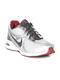

In [34]:
Image('1836.jpg')

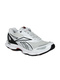

In [35]:
Image(filenames[indices[0][1]])

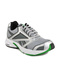

In [36]:
Image(filenames[indices[0][2]])

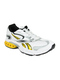

In [37]:
Image(filenames[indices[0][3]])

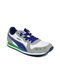

In [38]:
Image(filenames[indices[0][4]])

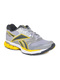

In [39]:
Image(filenames[indices[0][5]])